# 03 - Word Embeddings
## Yelp Review Rating Prediction
Goal: set up from TF-IDF's bag-of-words representation to pretrained word embeddings (GloVe), and see whether capturing word meaning (embeddings place similar words near each other in vector space) beats TF-IDF's word frequency approach.
**Recap - TF-IDF base baseline (notebook 02):**</br>
* Logistic Regression: macro-F1 **0.573**, weighted F1 **0.573**
* Naive Bayes: macro-F1 **0.553**
* Errors clustered near the diagonal (adjacent-star confusion) - classes 1 and 5 were easiest, 2-4 hardest </br>

**Worth knowing going in:** averaging word vectors per review (standard simple approach, used below) throws away word order entirely - arguably more information loss than TF-IDF's bigrams, which at least capture some local word order. It's entirely possible this approach performs similarly to or even worse than the TF-IDF baseline.

In [1]:
import sys
from pathlib import Path

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

sys.path.append(str(Path("..") / "src"))
from preprocessing import clean_text
from eval_utils import save_result, load_results

sns.set_style("whitegrid")

## 0. Seed the results with notebook 02's numbers
So the final comparison in notebook 05 doesn't require manually re-copying metrics from memory - recording the already-known TF-IDF results here once.

In [2]:
save_result('TF-IDF + Logistic Regression', {
    "macro_f1": 0.5727, "weighted_f1": 0.5727,
})
save_result("TF-IDF + Naive Bayes", {
    "macro_f1": 0.5531, "weighted_f1": 0.5531,
})
load_results()

{'TF-IDF + Logistic Regression': {'macro_f1': 0.5727, 'weighted_f1': 0.5727},
 'TF-IDF + Naive Bayes': {'macro_f1': 0.5531, 'weighted_f1': 0.5531},
 'GloVe embeddings + Logistic Regression': {'macro_f1': 0.4756,
  'weighted_f1': 0.4756}}

## 1. Load the cleaned train/val split
Reusing the same split saved in notebook 02, so this is a fair apples-to-apples comparison against the TF-IDF base - same rows, same cleaning, only the text representation changes.

In [3]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")

TARGET = "stars"
print("Train:", train_df.shape, "Val:", val_df.shape)

Train: (14400, 3) Val: (3600, 3)


In [4]:
#fixing a bug in 'text_clean' column
train_df["text_clean"] = train_df["text_clean"].fillna("")
val_df["text_clean"] = val_df["text_clean"].fillna("")

## 2. Load pretrained GloVe embeddings
Using `gensim`'s downloader to grab pretrained GloVe vectors (trained on Wikipedia + Gigaword) rather than training embeddings from scratch - the whole point of this step is to test whether *general* pretrained word meaning transfers to this domain-specific task.</br>
**First run will download ~130MB** and take a few minutes; cached locally afterward.

In [5]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-100") #there should be 100-dimensional vectors
print("Vocabular size:", len(glove.key_to_index))
print("Vector dimension:", glove.vector_size)

Vocabular size: 400000
Vector dimension: 100


## 3. Average word vectors per review
The standard simple approach: represent each review as the average of it's GloVe vectors. Words not in GloVe's vocabulary (out-of-vocabular - typos, very rare words, etc.) are skipped rather than erroring.

In [6]:
def review_to_vector(text: str, model, dim: int = 100) -> np.ndarray:
    words = text.split()
    vectors = [model[w] for w in words if w in model.key_to_index]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

def oov_rate(text: str, model) -> float:
    """what fraction of words in this review aren't in GloVe's vocabular?
    Worth checking overall, a high OOV rate would mean embeddings are
    losing a lot of the review's actual content."""
    words = text.split()
    if not words:
        return 0.0
    oov = sum(1 for w in words if w not in model.key_to_index)
    return oov / len(words)

In [7]:
sample_oov_rates = train_df['text_clean'].sample(2000, random_state=42).apply(
    lambda t: oov_rate(t, glove)
)
print("Mean OOV rate on a 2000-review sample:", round(sample_oov_rates.mean(), 4))
print("Reviews with >20% OOV words:", (sample_oov_rates > 0.2).sum(), "/ 2000")

Mean OOV rate on a 2000-review sample: 0.0058
Reviews with >20% OOV words: 7 / 2000


The OOV rate for the 2000-review sample is relatively low, which means GloVe is covering this vocabulary well and any embeddings underperformance relative to TF-IDF isn't due to missing words.

In [8]:
X_train_emb = np.vstack(train_df['text_clean'].apply(lambda t: review_to_vector(t, glove)))
X_val_emb = np.vstack(val_df['text_clean'].apply(lambda t: review_to_vector(t, glove)))

y_train = train_df[TARGET]
y_val = val_df[TARGET]

print("Embedding feature matrix shape (train):", X_train_emb.shape)

Embedding feature matrix shape (train): (14400, 100)


## 4. Train classifier on the averaged embeddings
Using Logistic Regression again; the same model family as the TF-IDF baseline's best result, so any performance difference is attributable to the feature representation (TF-IDF vs. embeddings), not a different classifier confounding the comparison

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

#embeddings benefit from scaling (unlike sparse TF-IDF features) since
# they're dense, real-valued vectors without TF-IDF's built-in normalization
scaler = StandardScaler()
X_train_emb_scaled = scaler.fit_transform(X_train_emb)
X_val_emb_scaled = scaler.fit_transform(X_val_emb)

emb_logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
emb_logreg.fit(X_train_emb_scaled, y_train)

emb_pred = emb_logreg.predict(X_val_emb_scaled)

macro_f1 = f1_score(y_val, emb_pred, average='macro')
weighted_f1 = f1_score(y_val, emb_pred, average='weighted')

print('Macro F1:', round(macro_f1, 4))
print('Weighted F1:', round(weighted_f1, 4))
print()
print(classification_report(y_val, emb_pred, digits=3))

save_result('GloVe embeddings + Logistic Regression', {
    'macro_f1': round(macro_f1, 4), 'weighted_f1': round(weighted_f1, 4),
})

Macro F1: 0.4756
Weighted F1: 0.4756

              precision    recall  f1-score   support

           1      0.614     0.724     0.664       720
           2      0.413     0.390     0.401       720
           3      0.371     0.358     0.364       720
           4      0.409     0.383     0.396       720
           5      0.560     0.544     0.552       720

    accuracy                          0.480      3600
   macro avg      0.473     0.480     0.476      3600
weighted avg      0.473     0.480     0.476      3600



{'TF-IDF + Logistic Regression': {'macro_f1': 0.5727, 'weighted_f1': 0.5727},
 'TF-IDF + Naive Bayes': {'macro_f1': 0.5531, 'weighted_f1': 0.5531},
 'GloVe embeddings + Logistic Regression': {'macro_f1': np.float64(0.4756),
  'weighted_f1': np.float64(0.4756)}}

## 5. Confusion matrix - compare the error pattern to TF-IDF 
Same diagonal clustering question as notebook 02: does this approach make different kinds of mistakes, or just more/fewer of the same kind?

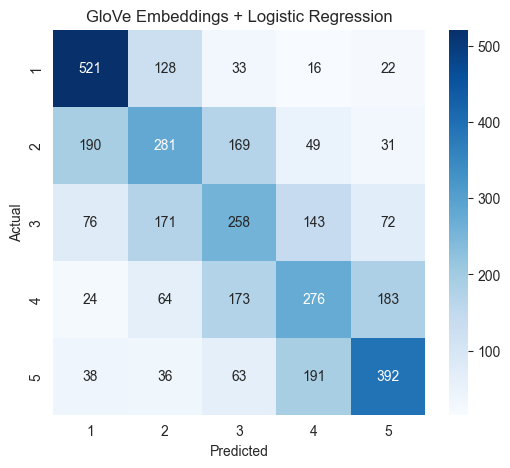

In [10]:
cm = confusion_matrix(y_val, emb_pred)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(1,6), yticklabels=range(1,6))
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('GloVe Embeddings + Logistic Regression')
plt.show()

Here we see a similar problem in notebook 02; the model is really good at predicted 1-star or 5-star reviews, but breaks down between 2-4. We also see that the model incorrectly predicted a 2-star review when it was actually a 3-star review, as an example.

## 6. Direct comparison against the TF-IDF baseline

In [11]:
results_df = pd.DataFrame(load_results()).T.sort_values('macro_f1', ascending=False)
results_df

,macro_f1,weighted_f1
TF-IDF + Logistic Regression,0.5727,0.5727
TF-IDF + Naive Bayes,0.5531,0.5531
GloVe embeddings + Logistic Regression,0.4756,0.4756


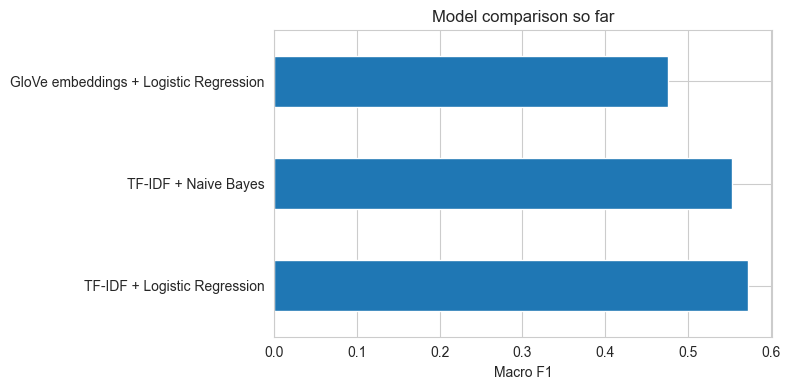

In [12]:
results_df['macro_f1'].plot(kind='barh', figsize=(8, 4))
plt.xlabel('Macro F1')
plt.title('Model comparison so far')
plt.tight_layout()
plt.show()

The TF-IDF + Logistic Regression model beat the GloVe embeddings + Logistic Regression model; perhaps averaging destroys word order and general domain pretrained vectors vs. this specific casual review vocabulary doesn't work well

## 7. A production consideration worth noting
Unlike the TF-IDF baseline (a single small `.joblib` file), serving this approach in production would require bundling the ~130MB GloVe vectors alongside the trained classifier, a meaningfully heavier deployment than TF-IDF, for a result that may not even be better.</br>
Saving just the classifier here (not the GloVe vectors) - if this approach is chosen aas final in notebook 05, this deployment cost would need revisiting.

In [13]:
import joblib

joblib.dump(
    {'scaler': scaler, 'model': emb_logreg},
    '../models/embeddings_baseline.joblib',
)
print("Saved embeddings classifier (excluding GloVe vectors) to models/embedding_baseline.joblib")

Saved embeddings classifier (excluding GloVe vectors) to models/embedding_baseline.joblib


## 8. Summary
After running the GloVe embeddings + Logistic Regression, the best model is still the TF-IDF + Logistic Regression; the macro F1 is 0.5727 versus the embeddings 0.4756. The OOV rate finding from the glove embedding was less than 1%, at 0.0058. The confusion matrix for the embedding had a similar issue to the TF-IDF, where its better at predicted 1-star or 5-star reviews. </br>
For now, it makes sense to move forward with the TF-IDF model for both accuracy and practicality. </br>
Next: `04_transformer_finetune.ipynb` - fine tuning DistilBERT, which (unlike averaged embeddings) can actuall use word order and context.